# 🔒 PII Detector and Masker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-infra-toolkit/pii-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-infra-toolkit/pii-detector/demo.ipynb)

> Scan datasets for personally identifiable information (PII) and mask it before sharing with staging, analytics, or third parties.

**What this notebook covers:**
1. Define regex patterns for 7 PII types (email, phone, SSN, credit card, IP, DOB, zip)
2. Scan a sample employee dataset for PII
3. Visualize PII distribution across columns
4. Apply smart masking (partial redaction preserving utility)
5. Try it on your own data

## Step 1: Setup and PII Pattern Definitions

We define regex patterns for 7 common PII types. Each pattern is tuned to catch real-world formatting variations (dashes, dots, parentheses in phone numbers, etc.).

In [1]:
from __future__ import annotations

import re
from typing import Dict, List, Optional, Tuple

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# PII type definitions and their regex patterns
PII_PATTERNS: Dict[str, re.Pattern] = {
    "Email": re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b"),
    "Phone (US)": re.compile(r"\b(?:\+?1[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)?\d{3}[-.\s]?\d{4}\b"),
    "SSN": re.compile(r"\b\d{3}-\d{2}-\d{4}\b"),
    "Credit Card": re.compile(r"\b(?:\d[ -]*?){13,16}\b"),
    "IP Address": re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"),
    "Date of Birth": re.compile(r"\b(?:0[1-9]|1[0-2])[/-](?:0[1-9]|[12]\d|3[01])[/-](?:19|20)\d{2}\b"),
    "US Zip Code": re.compile(r"\b\d{5}(?:-\d{4})?\b"),
}

MASK_CHAR = "\u2588"  # full block character

print(f"Loaded {len(PII_PATTERNS)} PII detection patterns")
for name in PII_PATTERNS:
    print(f"  \u2713 {name}")

Loaded 7 PII detection patterns
  ✓ Email
  ✓ Phone (US)
  ✓ SSN
  ✓ Credit Card
  ✓ IP Address
  ✓ Date of Birth
  ✓ US Zip Code


## Step 2: Sample Dataset

Here's a typical employee/customer dataset that might get shared with a staging environment or third-party vendor — full of PII that should never leave production.

In [2]:
df = pd.DataFrame({
    "employee_id": ["EMP001", "EMP002", "EMP003", "EMP004", "EMP005"],
    "name": ["Alice Johnson", "Bob Smith", "Carol Williams", "Dave Brown", "Eve Davis"],
    "email": [
        "alice.johnson@acme.com", "bob.smith@gmail.com",
        "carol.w@company.org", "dave.b@startup.io", "eve.davis@example.net",
    ],
    "phone": [
        "(555) 123-4567", "555-987-6543", "+1 555.246.8135",
        "555-369-2580", "(555) 147-2583",
    ],
    "ssn": [
        "123-45-6789", "987-65-4321", "456-78-9012",
        "321-54-9876", "654-32-1098",
    ],
    "notes": [
        "Workstation IP: 192.168.1.100",
        "DOB: 03/15/1990, backup email: bob2@mail.com",
        "Card on file: 4111-1111-1111-1111",
        "Home zip: 94102-3456",
        "Secondary email: eve2@backup.com, DOB: 11/22/1985",
    ],
})

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df

Dataset: 5 rows x 6 columns


,employee_id,name,email,phone,ssn,notes
0,EMP001,Alice Johnson,alice.johnson@acme.com,(555) 123-4567,123-45-6789,Workstation IP: 192.168.1.100
1,EMP002,Bob Smith,bob.smith@gmail.com,555-987-6543,987-65-4321,"DOB: 03/15/1990, backup email: bob2@mail.com"
2,EMP003,Carol Williams,carol.w@company.org,+1 555.246.8135,456-78-9012,Card on file: 4111-1111-1111-1111
3,EMP004,Dave Brown,dave.b@startup.io,555-369-2580,321-54-9876,Home zip: 94102-3456
4,EMP005,Eve Davis,eve.davis@example.net,(555) 147-2583,654-32-1098,"Secondary email: eve2@backup.com, DOB: 11/22/1985"


## Step 3: Scan for PII

We scan every cell in the DataFrame against all PII patterns and collect matches with their location (column, row) and type.

In [3]:
def scan_for_pii(df: pd.DataFrame) -> List[Dict]:
    """Scan all cells in a DataFrame for PII matches."""
    matches = []
    for col in df.columns:
        for row_idx, cell in enumerate(df[col].astype(str)):
            for pii_type, pattern in PII_PATTERNS.items():
                for m in pattern.finditer(cell):
                    matches.append({
                        "type": pii_type,
                        "value": m.group(),
                        "column": col,
                        "row": row_idx,
                    })
    return matches


matches = scan_for_pii(df)
print(f"\n\u26a0\ufe0f  Found {len(matches)} PII items across {len(df.columns)} columns\n")

findings = pd.DataFrame(matches)
findings


⚠️  Found 23 PII items across 6 columns



,type,value,column,row
0,Email,alice.johnson@acme.com,email,0
1,Email,bob.smith@gmail.com,email,1
2,Email,carol.w@company.org,email,2
3,Email,dave.b@startup.io,email,3
4,Email,eve.davis@example.net,email,4
5,Phone (US),555) 123-4567,phone,0
6,Phone (US),555-987-6543,phone,1
7,Phone (US),1 555.246.8135,phone,2
8,Phone (US),555-369-2580,phone,3
9,Phone (US),555) 147-2583,phone,4


## Step 4: Visualize PII Distribution

A heatmap shows which columns carry the most PII risk — helpful for deciding which columns to mask, drop, or restrict access to.

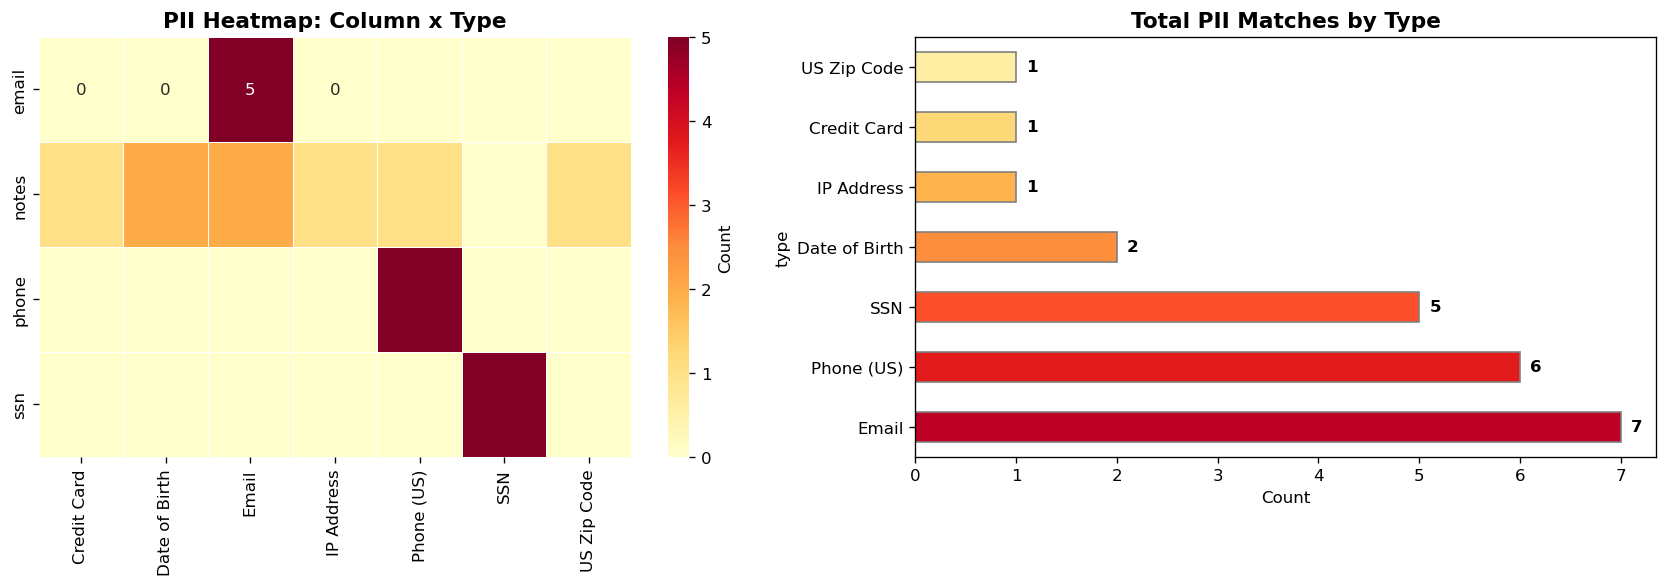

✅ Chart saved to pii_report.png


In [4]:
import seaborn as sns

# Build a pivot: columns vs PII types
pivot = findings.groupby(["column", "type"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap: PII types per column
sns.heatmap(
    pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
    ax=axes[0], cbar_kws={"label": "Count"},
)
axes[0].set_title("PII Heatmap: Column x Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# Bar chart: total PII by type
type_counts = findings["type"].value_counts()
colors = sns.color_palette("YlOrRd_r", len(type_counts))
type_counts.plot.barh(ax=axes[1], color=colors, edgecolor="gray")
axes[1].set_title("Total PII Matches by Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Count")
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 0.1, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("pii_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 Chart saved to pii_report.png")

## Step 5: Smart Masking

Rather than replacing everything with `***`, we use **smart masking** that preserves partial utility:
- **Email:** `a████@acme.com` (keep first char + domain)
- **SSN:** `XXX-XX-6789` (keep last 4)
- **Credit Card:** `███████████1111` (keep last 4)
- **Phone:** `███████4567` (keep last 4)

In [5]:
def mask_value(value: str, pii_type: str) -> str:
    """Apply smart masking based on PII type."""
    if pii_type == "Email":
        local, domain = value.split("@", 1)
        return f"{local[0]}{MASK_CHAR * (len(local) - 1)}@{domain}"
    if pii_type == "SSN":
        return f"XXX-XX-{value[-4:]}"
    if pii_type == "Credit Card":
        digits = re.sub(r"\D", "", value)
        return f"{MASK_CHAR * (len(digits) - 4)}{digits[-4:]}"
    if pii_type == "Phone (US)":
        digits = re.sub(r"\D", "", value)
        if len(digits) >= 4:
            return f"{MASK_CHAR * (len(digits) - 4)}{digits[-4:]}"
    return MASK_CHAR * len(value)


def mask_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Apply PII masking to all cells in a DataFrame."""
    masked = df.copy()
    for col in masked.columns:
        for pii_type, pattern in PII_PATTERNS.items():
            masked[col] = masked[col].astype(str).apply(
                lambda cell, p=pattern, pt=pii_type: p.sub(
                    lambda m: mask_value(m.group(), pt), cell
                )
            )
    return masked


masked_df = mask_dataframe(df)
print("\u2705 Masked dataset (safe to share):\n")
masked_df

✅ Masked dataset (safe to share):



,employee_id,name,email,phone,ssn,notes
0,EMP001,Alice Johnson,a████████████@acme.com,(██████4567,XXX-XX-6789,Workstation IP: █████████████
1,EMP002,Bob Smith,b████████@gmail.com,██████6543,XXX-XX-4321,"DOB: ██████████, backup email: b███@mail.com"
2,EMP003,Carol Williams,c██████@company.org,+███████8135,XXX-XX-9012,Card on file: 4111-████1111-1111
3,EMP004,Dave Brown,d█████@startup.io,██████2580,XXX-XX-9876,Home zip: ██████████
4,EMP005,Eve Davis,e████████@example.net,(██████2583,XXX-XX-1098,"Secondary email: e███@backup.com, DOB: ██████████"


## Step 6: Before vs. After Comparison

Let's verify the masking worked by comparing a few key columns side by side.

In [6]:
comparison = pd.DataFrame({
    "Original Email": df["email"],
    "Masked Email": masked_df["email"],
    "Original SSN": df["ssn"],
    "Masked SSN": masked_df["ssn"],
    "Original Phone": df["phone"],
    "Masked Phone": masked_df["phone"],
})

print("Before vs. After masking:\n")
comparison

Before vs. After masking:



,Original Email,Masked Email,Original SSN,Masked SSN,Original Phone,Masked Phone
0,alice.johnson@acme.com,a████████████@acme.com,123-45-6789,XXX-XX-6789,(555) 123-4567,(██████4567
1,bob.smith@gmail.com,b████████@gmail.com,987-65-4321,XXX-XX-4321,555-987-6543,██████6543
2,carol.w@company.org,c██████@company.org,456-78-9012,XXX-XX-9012,+1 555.246.8135,+███████8135
3,dave.b@startup.io,d█████@startup.io,321-54-9876,XXX-XX-9876,555-369-2580,██████2580
4,eve.davis@example.net,e████████@example.net,654-32-1098,XXX-XX-1098,(555) 147-2583,(██████2583


## Step 7: Risk Score Summary

Generate a per-column risk score based on PII density (PII matches / total cells). Columns above 50% are high-risk and should be dropped or heavily restricted.

In [7]:
risk_scores = []
for col in df.columns:
    col_matches = len([m for m in matches if m["column"] == col])
    density = col_matches / len(df)
    risk = "HIGH" if density >= 0.5 else "MEDIUM" if density > 0 else "LOW"
    risk_scores.append({
        "Column": col,
        "PII Count": col_matches,
        "Density": f"{density:.0%}",
        "Risk Level": risk,
        "Recommendation": "MASK or DROP" if risk == "HIGH" else "REVIEW" if risk == "MEDIUM" else "OK",
    })

risk_df = pd.DataFrame(risk_scores)
print("Column Risk Assessment:\n")
risk_df

Column Risk Assessment:



,Column,PII Count,Density,Risk Level,Recommendation
0,employee_id,0,0%,LOW,OK
1,name,0,0%,LOW,OK
2,email,5,100%,HIGH,MASK or DROP
3,phone,5,100%,HIGH,MASK or DROP
4,ssn,5,100%,HIGH,MASK or DROP
5,notes,8,160%,HIGH,MASK or DROP


## Try Your Own Data

Uncomment and modify the code below to scan your own CSV:

In [8]:
# --- Uncomment to try with your own data ---
# my_df = pd.read_csv("your_data.csv")
# my_matches = scan_for_pii(my_df)
# print(f"Found {len(my_matches)} PII items")
# pd.DataFrame(my_matches)
#
# my_masked = mask_dataframe(my_df)
# my_masked.to_csv("your_data_masked.csv", index=False)
# print("Masked file saved!")

---

**[Back to Portfolio →](https://github.com/phoebefu6/phoebe-the-builder)**

For the full interactive Streamlit app with file upload + download: `streamlit run app.py`